# Which task is more heterogeneous — and which gives bigger prediction sets?
*A head-to-head comparison of the two classification tasks, using **every** feature.*

We put the **5-class disease-severity** task and the **4-class chest-pain** task side by side and ask two questions:

1. **Which task carries more site-level heterogeneity?**
2. **Which task yields more conformal labels per sample** (larger prediction sets)?

Each task uses all columns except its own label as features, so the disease model uses the 13 clinical variables (including chest-pain type) and the chest-pain model uses the other 12 plus the disease target. The analysis logic lives in `scripts/compare_prediction_tasks.py`; we import and call it here so the notebook stays in sync with the script.

In [ ]:
# --- workshop bootstrap: make the package importable ---
import sys, os

def _find_deliverables_root():
    """Locate the folder that contains src/fedconformal + data/ -- resolves
    relative to this notebook in classic Jupyter/JupyterLab, and searches
    Google Drive (after mounting it) in Colab."""
    candidates = [os.path.abspath(os.path.join(os.getcwd(), '..'))]
    try:
        import google.colab  # noqa: F401
        from google.colab import drive
        if not os.path.isdir('/content/drive/MyDrive'):
            drive.mount('/content/drive')
        root = '/content/drive/MyDrive'
        candidates += [root, os.path.join(root, 'deliverables'),
                       os.path.join(root, 'Colab Notebooks', 'deliverables')]
        for name in sorted(os.listdir(root)):
            candidates.append(os.path.join(root, name))
            candidates.append(os.path.join(root, name, 'deliverables'))
    except ImportError:
        pass
    for c in candidates:
        if os.path.isdir(os.path.join(c, 'src', 'fedconformal')):
            return os.path.abspath(c)
    raise RuntimeError(
        "Could not find the 'deliverables' folder (needs a src/fedconformal "
        "subfolder). In Colab, upload the WHOLE 'deliverables' folder (not just "
        "this notebook) to your Google Drive, then re-run this cell."
    )

_ROOT = _find_deliverables_root()
sys.path.insert(0, os.path.join(_ROOT, 'src'))
import numpy as np, pandas as pd
from fedconformal import data, conformal, evaluate as ev, federated, heterogeneity as het, viz, eda, paper_figures as pf
viz.set_style()
%matplotlib inline
# load the federation once (each notebook is self-contained)
df = data.load_raw()
sites = data.load_sites(shared_scaler=True)
sys.path.insert(0, os.path.join(_ROOT, 'scripts'))
import compare_prediction_tasks as ct

## Run the comparison
For each task this trains one shared model on all four sites, measures three kinds of heterogeneity, and computes the average conformal set size (APS, α = 0.1).

In [2]:
df = data.load_raw()
dz = ct.analyze(df, 'disease')
cp = ct.analyze(df, 'cp')
tbl = pd.DataFrame([dz, cp]).set_index('task')[[
    'n_features','K','label_js','domain_auc','cov_off_mean',
    'cov_worst','cov_drop','marginal_cov','avg_set_size','avg_set_size_norm']]
tbl.round(3)

,n_features,K,label_js,domain_auc,cov_off_mean,cov_worst,cov_drop,marginal_cov,avg_set_size,avg_set_size_norm
task,,,,,,,,,,
disease,13,5,0.128,0.930,0.909,0.87,-0.009,0.905,2.681,0.536
cp,13,4,0.073,0.929,0.910,0.88,-0.010,0.906,2.252,0.563


Column guide: `label_js` = mean pairwise Jensen–Shannon divergence between the four sites' class distributions (label shift); `domain_auc` = mean pairwise domain-classifier AUC (covariate shift); `cov_off_mean` / `cov_worst` = mean / worst cross-site coverage; `cov_drop` = target − mean cross-site coverage; `avg_set_size` = conformal labels per sample; `avg_set_size_norm` = that divided by the number of classes.

## The picture

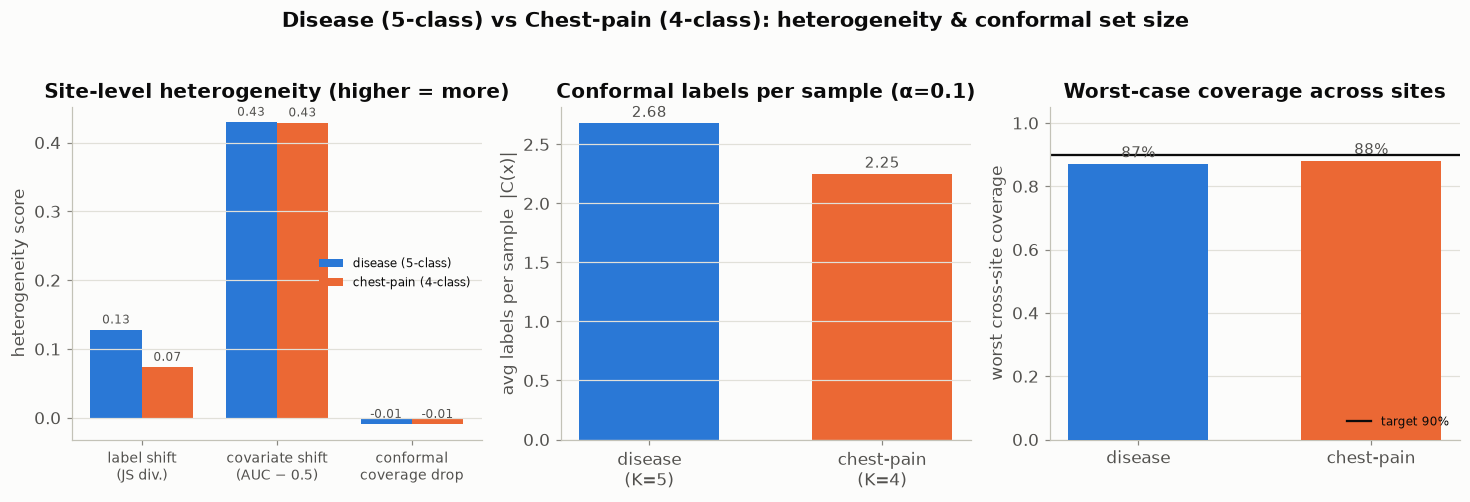

In [3]:
ct.plot_comparison(dz, cp);

## Verdict

In [4]:
more_het  = 'chest-pain' if cp['label_js']  > dz['label_js']  else 'disease'
more_sets = 'chest-pain' if cp['avg_set_size'] > dz['avg_set_size'] else 'disease'
print(f"Label-shift heterogeneity higher in : {more_het}  "
      f"(JS {max(cp['label_js'],dz['label_js']):.3f} vs {min(cp['label_js'],dz['label_js']):.3f})")
print(f"More conformal labels per sample in : {more_sets}  "
      f"(|C| {max(cp['avg_set_size'],dz['avg_set_size']):.2f} vs "
      f"{min(cp['avg_set_size'],dz['avg_set_size']):.2f})")

Label-shift heterogeneity higher in : disease  (JS 0.128 vs 0.073)
More conformal labels per sample in : disease  (|C| 2.68 vs 2.25)


**Reading the result.** The **5-class disease-severity** task is the more heterogeneous across sites by label shift (JS ≈ 0.13 vs ≈ 0.07 for chest-pain — the severity mix swings far more across hospitals than chest-pain type does), and it also produces the larger raw prediction sets (~2.7 labels/sample vs ~2.3), simply because it has one more class. Normalised by the number of classes the two tasks are close (chest-pain fills a slightly *larger* fraction of its label space), so once you account for K the two tasks carry comparable local uncertainty — the real gap between them is in cross-site label shift, not set size. At matched conditions, APS keeps cross-site coverage close to the 90% target for both (worst-case site still ≈ 87-88%) — so here heterogeneity shows up mainly as label shift, not as a large coverage break.

### Exercise
1. Re-run with `ALPHA` changed in `compare_prediction_tasks.py` (e.g. 0.05). How do the set sizes and the verdict move?
2. Restrict each task to a *shared* 12-feature set (drop the other task's label from the features) and re-compute. Does using 'every feature' change which task looks more heterogeneous?